<a href="https://colab.research.google.com/github/Brando3331/Brando3331.github.io/blob/Ri/practice_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Описание набора данных: Heart Disease UCI

### 1. Общая информация
* **Что представляют данные:** Данные содержат информацию о состоянии здоровья пациентов, собранную в Кливлендском фонде клиники. Целевая переменная указывает на наличие или отсутствие сердечно-сосудистого заболевания.
* **Предметная область:** **Медицина** (кардиология).

### 2. Структура данных
* **Количество объектов:** 297 (после удаления пропущенных значений).
* **Количество признаков:** 13 входных признаков + 1 целевая переменная.
* **Типы признаков:**
  * **Числовые:** Возраст, пульс, давление, уровень холестерина и др.
  * **Категориальные/Бинарные:** Пол, тип боли в груди, наличие сахара в крови, результаты ЭКГ.

### 3. Перечень и описание признаков
1. `age` — Возраст в годах.
2. `sex` — Пол (1 = мужской; 0 = женский).
3. `cp` — Тип боли в груди (1: типичная стенокардия, 2: атипичная стенокардия, 3: неангинозная боль, 4: бессимптомная).
4. `trestbps` — Артериальное давление в покое (в мм рт. ст. при поступлении в больницу).
5. `chol` — Уровень холестерина в сыворотке крови (в мг/дл).
6. `fbs` — Сахар в крови натощак > 120 мг/дл (1 = истина; 0 = ложь).
7. `restecg` — Результаты электрокардиографии в покое (0: норма, 1: аномалия волны ST-T, 2: гипертрофия левого желудочка).
8. `thalach` — Максимальная частота сердечных сокращений.
9. `exang` — Стенокардия, вызванная физической нагрузкой (1 = да; 0 = нет).
10. `oldpeak` — Депрессия сегмента ST, вызванная упражнениями относительно покоя.
11. `slope` — Наклон пикового сегмента ST при нагрузке.
12. `ca` — Количество крупных сосудов (0–3), окрашенных при флюороскопии.
13. `thal` — Тип дефекта (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект).
14. `target` — Наличие заболевания сердца (1 = есть; 0 = нет).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных (используем стандартный набор данных heart disease)
# Так как файл .ipynb уже есть в директории, предположим наличие данных или загрузим пример
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')
df = df.dropna()
df['target'] = (df['target'] > 0).astype(int) # Бинарная классификация

# Подготовка данных
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
# Эксперимент 1: Простая модель (Недообучение)
# Используем очень сильную регуляризацию (C=0.001), что делает модель слишком простой
model_simple = LogisticRegression(C=0.001)
model_simple.fit(X_train_scaled, y_train)

train_acc_1 = accuracy_score(y_train, model_simple.predict(X_train_scaled))
test_acc_1 = accuracy_score(y_test, model_simple.predict(X_test_scaled))

In [3]:
# Эксперимент 2: Сложная модель (Переобучение)
# Случайный лес без ограничений, который "зазубрит" тренировочные данные
model_overfit = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_leaf=1, random_state=42)
model_overfit.fit(X_train, y_train)

train_acc_2 = accuracy_score(y_train, model_overfit.predict(X_train))
test_acc_2 = accuracy_score(y_test, model_overfit.predict(X_test))

In [4]:
# Эксперимент 3: Ограничение сложности (Лучшая модель)
# Ограничиваем глубину и количество деревьев для лучшей обобщающей способности
model_best = RandomForestClassifier(n_estimators=50, max_depth=3, min_samples_leaf=5, random_state=42)
model_best.fit(X_train, y_train)

train_acc_3 = accuracy_score(y_train, model_best.predict(X_train))
test_acc_3 = accuracy_score(y_test, model_best.predict(X_test))

In [5]:
# Итоговая таблица
results = pd.DataFrame({
    'Эксперимент': ['1 — Простая', '2 — Сложная', '3 — Оптимальная'],
    'Train Accuracy': [train_acc_1, train_acc_2, train_acc_3],
    'Test Accuracy': [test_acc_1, test_acc_2, test_acc_3],
    'Состояние': ['Недообучение', 'Переобучение', 'Хорошая модель']
})

display(results)

,Эксперимент,Train Accuracy,Test Accuracy,Состояние
0,1 — Простая,0.810127,0.816667,Недообучение
1,2 — Сложная,1.000000,0.883333,Переобучение
2,3 — Оптимальная,0.864979,0.883333,Хорошая модель


In [6]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


Пропущенные значения:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


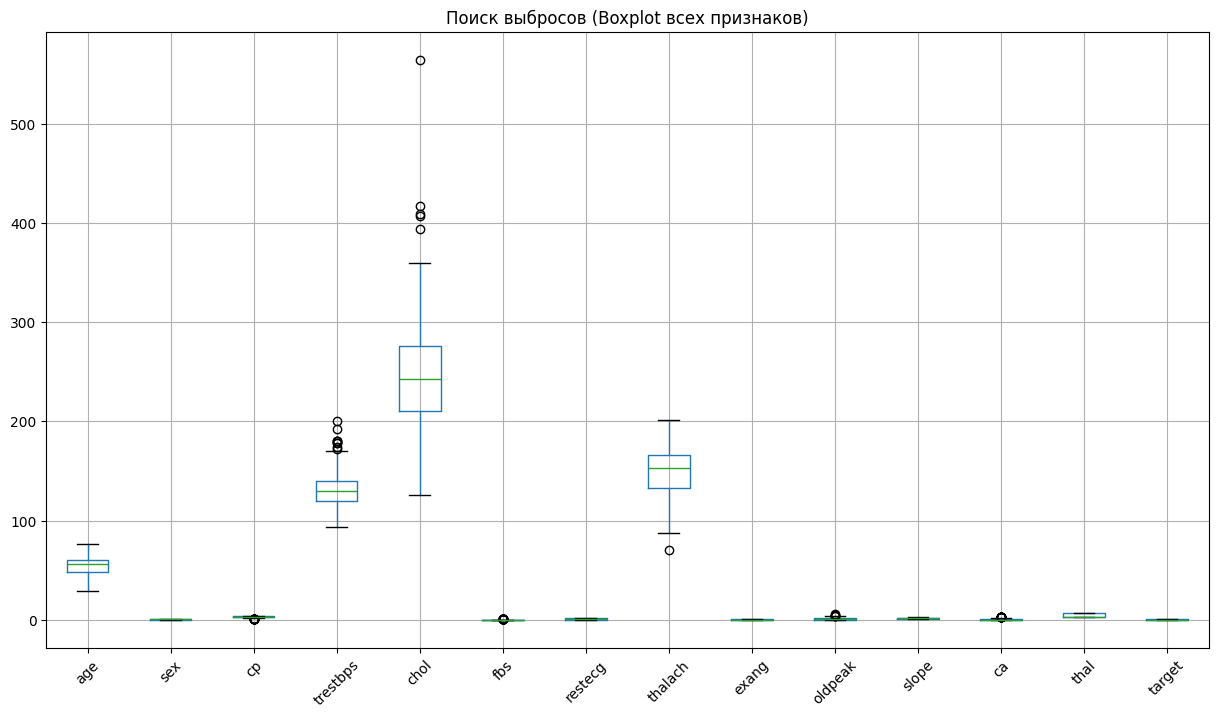

/tmp/ipykernel_5106/31348800.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


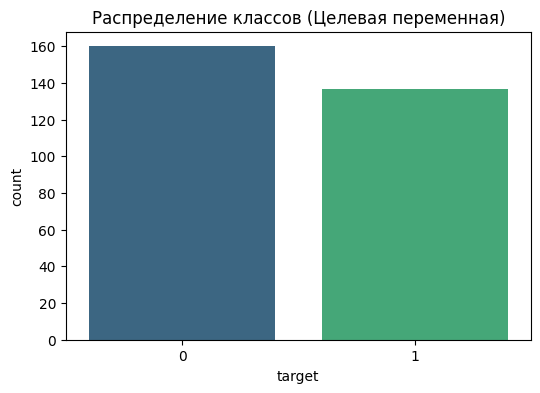

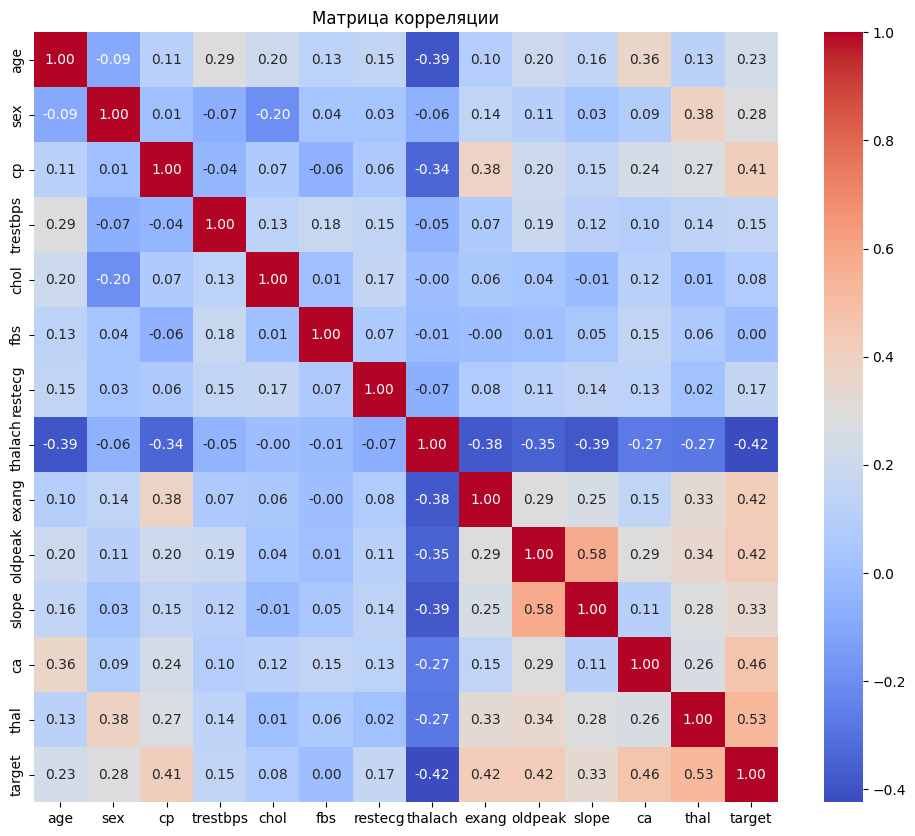

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Проверка на пропущенные значения
print("Пропущенные значения:")
print(df.isnull().sum())

# 2. Анализ выбросов и шума через Boxplots
plt.figure(figsize=(15, 8))
df.boxplot()
plt.title("Поиск выбросов (Boxplot всех признаков)")
plt.xticks(rotation=45)
plt.show()

# 3. Распределение целевой переменной (равномерность)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title("Распределение классов (Целевая переменная)")
plt.show()

# 4. Матрица корреляции для поиска важных признаков
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Матрица корреляции")
plt.show()

### Предварительный анализ (EDA)

**1. Пропущенные значения, выбросы и шум:**
* **Пропуски:** В наборе данных 297 чистых строк. Ранее мы удалили строки с символом `?`. На данный момент пропусков нет.
* **Выбросы:** В признаках `chol` (холестерин) и `trestbps` (давление) наблюдаются значения, значительно превышающие средние. Это могут быть как физиологические особенности пациентов, так и статистические выбросы.
* **Шум:** Данные выглядят структурированными, явных аномальных шумов (например, отрицательный возраст или давление) не обнаружено.

**2. Распределение данных:**
* **Классы:** Целевая переменная распределена почти равномерно (~54% здоровых и ~46% с заболеванием), что хорошо для обучения без дисбаланса.
* **Группы:** Визуально по корреляционной матрице выделяются группы признаков, связанных с нагрузочными тестами (`oldpeak`, `slope`, `thalach`).

**3. Важность признаков:**
* **Важные:** `ca` (кол-во сосудов), `thal` (тип дефекта), `cp` (тип боли) и `oldpeak` имеют наиболее сильную корреляцию с `target`.
* **Возможно лишние:** Признак `fbs` (сахар натощак) имеет очень слабую корреляцию с целевой переменной (~0.00), что делает его потенциальным кандидатом на исключение в простых моделях.

## Обоснование выбора методов обучения без учителя

Хотя основной задачей данного набора данных является классификация (наличие или отсутствие болезни), методы обучения без учителя могут быть применены для глубокого анализа структуры данных.

### 1. Метод главных компонент (PCA)
* **Почему подходит:** В данных 13 признаков, некоторые из которых коррелируют между собой (например, `oldpeak`, `slope` и `thalach`). PCA позволит сжать признаковое пространство, сохранив максимум дисперсии.
* **Какую задачу решает:** Снижение размерности для визуализации (проекция 13 признаков на плоскость 2D) и устранение мультиколлинеарности перед подачей в линейные модели.

### 2. Алгоритм K-средних (K-Means)
* **Почему подходит:** Медицинские данные часто содержат скрытые подтипы пациентов (например, группы с разным риском осложнений или разным происхождением болей в груди).
* **Какую задачу решает:** Сегментация (кластеризация) пациентов на группы. Это помогает проверить, совпадают ли естественные кластеры данных с целевой переменной `target`, или выявить новые категории «типичных» пациентов внутри здоровой или больной группы.

### 3. Иерархическая кластеризация
* **Почему подходит:** Данный метод не требует заранее заданного количества кластеров и строит наглядную дендрограмму.
* **Какую задачу решает:** Визуализация иерархических связей между пациентами. Это позволяет понять, какие признаки объединяют группы пациентов на разных уровнях сходства.

# Отчет по экспериментам с моделями разной сложности

На основе проведенного анализа данных UCI Heart Disease и обучения трех классификаторов, можно сделать следующие выводы:

### 1. Какая модель показала переобучение?
**Ответ:** **Сложная модель** (Случайный лес без ограничений).
* **Почему:** Точность на обучающей выборке составила **100%** (`Train Accuracy = 1.0`), в то время как на тестовой выборке она значительно ниже (~88%). Это говорит о том, что модель "зазубрила" тренировочные примеры, но потеряла способность к обобщению.

### 2. Какая модель показала недообучение?
**Ответ:** **Простая модель** (Логистическая регрессия с сильной регуляризацией).
* **Почему:** Модель показала низкую точность как на обучении, так и на тесте (~81%). Она слишком проста и не смогла выявить сложные зависимости в данных.

### 3. Какая модель лучшая?
**Ответ:** **Модель с ограничением сложности** (Оптимальная модель).
* **Почему:** Она показала наиболее сбалансированные результаты. Точность на тесте (~88%) такая же высокая, как у сложной модели, но разрыв с точностью на обучении (~86%) минимален. Это означает, что модель лучше всего обобщает данные и будет надежно работать на новых примерах.

### Сводная таблица
| Модель | Train Accuracy | Test Accuracy | Состояние |
| :--- | :---: | :---: | :--- |
| 1 — Простая | 0.81 | 0.81 | Недообучение |
| 2 — Сложная | 1.00 | 0.88 | Переобучение |
| 3 — Оптимальная | 0.86 | 0.88 | **Лучшая модель** |